# ATLAS Solar Plotting Tutorial

This notebook creates maps from the final ATLAS solar files produced by the previous processing step.

The expected input folder is:

`../data/atlas_data/{country}/`

The figures are saved in:

`../data/figures/{country}/`

You can plot either one monthly file or the annual mean. When the annual mean is requested, the notebook opens the monthly files one by one, assigns the month coordinate, concatenates them, and then computes the mean across the `month` dimension. This avoids relying on a single pre-existing annual file.

## Step 1. Import libraries

Run this cell first. It loads the libraries needed to open NetCDF files and generate maps.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

warnings.filterwarnings("ignore")

## Step 2. Set input parameters

Edit only this cell for a new country or variable.

Parameter description:

`country`: country name used in the folder and file names.

`variable`: variable to plot. For this workflow the default variable is `ghi`.

`plot_annual_mean`: set to `True` to plot the annual mean, or `False` to plot a single month.

`month`: month to plot when `plot_annual_mean = False`. Use values from 1 to 12.

`vmin` and `vmax`: minimum and maximum values used for the map color scale.

`input_path`: folder containing the final ATLAS files from the scaling step.

`output_path`: folder where the figures will be saved.

In [2]:
# Country and variable
country = "peru"
variable = "ssrd"

# Plot settings
plot_annual_mean = False
month = 1

# Color scale limits for solar radiation in kWh/m²/day used in the Global Solar Atlas
vmin = 2
vmax = 9

# Input and output folders
input_path = Path(f"../data/atlas_data/{country}/")
output_path = Path(f"../data/figures/{country}/")
output_path.mkdir(parents=True, exist_ok=True)

## Step 3. Define file naming rules

The notebook assumes the monthly NetCDF files follow this structure:

`{variable}_integrated_{country}_m{month}.nc`

For example:

`ssrd_integrated_argentina_m1.nc`

If your files use a different naming convention, change only the function below.

In [3]:
def build_monthly_file_path(input_path, variable, country, month):
    """Return the expected path for one monthly integrated ATLAS file."""
    return Path(input_path) / f"{variable}_integrated_{country}_m{month}.nc"


def build_figure_file_path(output_path, variable, country, plot_annual_mean, month=None):
    """Return the output path for the map figure."""
    if plot_annual_mean:
        filename = f"{variable}_integrated_{country}_annual.png"
    else:
        filename = f"{variable}_integrated_{country}_m{month}.png"
    return Path(output_path) / filename

## Step 4. Define data loading functions

These functions open the NetCDF files.

For the annual mean, files are opened one by one, stored in a list, concatenated along a new `month` dimension, and averaged.

In [4]:
def find_data_variable(dataset, preferred_variable):
    """Find the data variable to plot inside an xarray Dataset."""
    if preferred_variable in dataset.data_vars:
        return preferred_variable

    integrated_name = f"{preferred_variable}_integrated"
    if integrated_name in dataset.data_vars:
        return integrated_name

    data_vars = list(dataset.data_vars)
    if len(data_vars) == 1:
        return data_vars[0]

    raise ValueError(
        "Could not identify the variable to plot. "
        f"Available variables are: {data_vars}. "
        f"Expected '{preferred_variable}' or '{integrated_name}'."
    )


def standardise_dataset(dataset):
    """Apply common spatial metadata and remove auxiliary spatial reference variables when present."""
    dataset = dataset.rio.write_crs("EPSG:4326")
    if "spatial_ref" in dataset.variables:
        dataset = dataset.drop_vars("spatial_ref")
    return dataset


def open_monthly_dataset(input_path, variable, country, month):
    """Open one monthly file and return it as an xarray Dataset."""
    file_path = build_monthly_file_path(input_path, variable, country, month)
    if not file_path.exists():
        raise FileNotFoundError(f"Monthly file not found: {file_path}")

    dataset = xr.open_dataset(file_path)
    dataset = standardise_dataset(dataset)
    return dataset


def open_annual_mean_dataset(input_path, variable, country, months=range(1, 13)):
    """Open monthly files one by one, concatenate them, and compute the annual mean."""
    monthly_datasets = []

    for selected_month in months:
        dataset = open_monthly_dataset(input_path, variable, country, selected_month)
        dataset = dataset.assign_coords(month=selected_month).expand_dims("month")
        monthly_datasets.append(dataset)

    combined = xr.concat(monthly_datasets, dim="month")
    annual_mean = combined.mean(dim="month", skipna=True)
    return annual_mean


def load_plot_dataset(input_path, variable, country, plot_annual_mean, month):
    """Load either the annual mean or a selected monthly dataset."""
    if plot_annual_mean:
        return open_annual_mean_dataset(input_path, variable, country)
    return open_monthly_dataset(input_path, variable, country, month)

## Step 5. Define plotting functions

These functions prepare grid cell edges and draw the map.

In [5]:
def cell_edges(coord):
    """Convert coordinate centres into coordinate edges for pcolormesh."""
    coord = np.asarray(coord, dtype=float)
    if coord.size < 2:
        raise ValueError("At least two coordinate values are required to calculate cell edges.")

    differences = np.diff(coord)
    edges = np.empty(coord.size + 1, dtype=float)
    edges[1:-1] = coord[:-1] + differences / 2
    edges[0] = coord[0] - differences[0] / 2
    edges[-1] = coord[-1] + differences[-1] / 2
    return edges


def draw_map(data_array, fig_path, vmin, vmax, title, label="kWh/m²/day", orientation="vertical"):
    """Draw and save a map from a gridded DataArray."""
    data_array = data_array.sortby("latitude")
    data_array = data_array.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    data_array = data_array.rio.write_crs("EPSG:4326")

    lon = data_array.longitude.values
    lat = data_array.latitude.values
    data = np.ma.masked_invalid(data_array.values)

    lon_edges = cell_edges(lon)
    lat_edges = cell_edges(lat)
    lon_grid, lat_grid = np.meshgrid(lon_edges, lat_edges)

    fig, ax = plt.subplots(
        figsize=(10, 12),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")
    ax.add_feature(cfeature.RIVERS, edgecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, edgecolor="black", linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidth=1.2)

    image = ax.pcolormesh(
        lon_grid,
        lat_grid,
        data,
        transform=ccrs.PlateCarree(),
        cmap="inferno_r",
        vmin=vmin,
        vmax=vmax,
        shading="flat",
        linewidth=0,
        antialiased=False
    )

    ticks = np.arange(vmin, vmax + 0.01, 0.5)
    colorbar = fig.colorbar(
        image,
        ax=ax,
        orientation=orientation,
        shrink=0.75,
        aspect=25,
        pad=0.04,
        ticks=ticks
    )
    colorbar.set_label(label, fontsize=20)
    colorbar.ax.tick_params(labelsize=16)

    gridlines = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.xformatter = LONGITUDE_FORMATTER
    gridlines.yformatter = LATITUDE_FORMATTER
    gridlines.xlabel_style = {"size": 16}
    gridlines.ylabel_style = {"size": 16}

    ax.set_extent(
        [lon.min() - 1, lon.max() + 1, lat.min() - 1, lat.max() + 1],
        crs=ccrs.PlateCarree()
    )

    ax.set_title(title, fontsize=22)
    fig_path = Path(fig_path)
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    return fig

## Step 6. Run the workflow

Run this cell after editing the parameters. It loads the selected dataset, creates the map, and saves the figure.

Figure saved to: ../data/figures/peru/ssrd_integrated_peru_m1.png


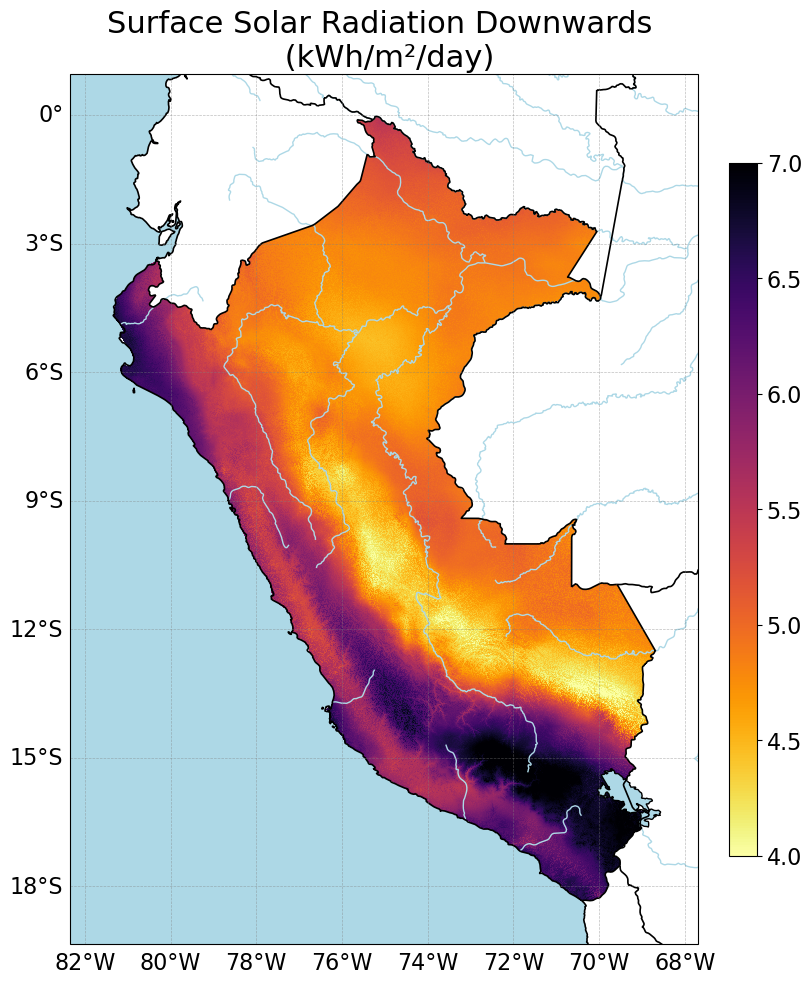

In [6]:
# Load data
plot_dataset = load_plot_dataset(
    input_path=input_path,
    variable=variable,
    country=country,
    plot_annual_mean=plot_annual_mean,
    month=month
)

# Select variable to plot
variable_to_plot = find_data_variable(plot_dataset, variable)
plot_data = plot_dataset[variable_to_plot]

# Define figure title and output path
if plot_annual_mean:
    period_label = "Annual mean"
else:
    period_label = f"Month {month}"

figure_path = build_figure_file_path(
    output_path=output_path,
    variable=variable,
    country=country,
    plot_annual_mean=plot_annual_mean,
    month=month
)

figure_title = "Surface Solar Radiation Downwards \n (kWh/m²/day)"

# Draw and save map
fig = draw_map(
    data_array=plot_data,
    fig_path=figure_path,
    vmin=vmin,
    vmax=vmax,
    title=figure_title,
    label= ''
)

print(f"Figure saved to: {figure_path}")